# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [3]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB

import statsmodels.api as sm
from statsmodels.formula.api import ols



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Single session

In [446]:
SESSIONS = [
    # 'M061_2025_03_04_10_00', 
    # 'M061_2025_03_05_14_00', 
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30', 
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
    # 'M103_2026_02_18_15_30',
    'M106_2026_02_25_15_00'

]
session_area_exclusions = {
    # 'M062_2025_03_20_14_00': ['VAL'],
    # 'M062_2025_03_21_14_00': ['SSp', 'CP'],
}

In [ ]:
td, _ = dsp.load_and_process_session(SESSIONS[0])

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).


In [510]:
Params.oscillating_key_points

['left_ankle',
 'left_elbow',
 'left_foot',
 'left_knee',
 'left_paw',
 'left_wrist',
 'right_ankle',
 'right_elbow',
 'right_foot',
 'right_knee',
 'right_paw',
 'right_wrist']

In [542]:
field = 'phases'
td_drop = dsp.drop_trials_sem_crosses_zero(td, std=True).copy()
td_drop.loc[:, field] = td_drop.apply(
    lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
    axis=1
)
td_drop.loc[:,"perturb_phase"] = td_drop["phases"].apply(lambda a: a[300, :])
td_drop.loc[:, f'forelimb_distance'] = td_drop["bhv"].apply(lambda a: np.mean(a[100:180, 1] - a[100:180, 7]))
td_drop.loc[:, f'hindlimb_distance'] = td_drop["bhv"].apply(lambda a: np.mean(a[100:180, 0] - a[100:180, 6]))
td_drop.loc[:, f'perturb_bhv'] = td_drop["bhv"].apply(lambda a: a[190, 1])



for idx in range(td_drop.perturb_phase.values[0].shape[0]):
    td_drop.loc[:, f'perturb_phase_{idx}_sin'] = np.sin(np.stack(td_drop.perturb_phase.values)[:, idx])
    td_drop.loc[:, f'perturb_phase_{idx}_cos'] = np.cos(np.stack(td_drop.perturb_phase.values)[:, idx])
    td_drop.loc[:, f'perturb_phase_{idx}'] = np.stack(td_drop.perturb_phase.values)[:, idx]


  drop_trials_sem_crosses_zero: by SEM: 167  |  by value: 309  |  kept: 151/325 (46.5%)


In [449]:
td_drop.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,perturb_phase_8,perturb_phase_9_sin,perturb_phase_9_cos,perturb_phase_9,perturb_phase_10_sin,perturb_phase_10_cos,perturb_phase_10,perturb_phase_11_sin,perturb_phase_11_cos,perturb_phase_11
1,M106,M106_2026_02_25_15_00,4,trial,600,0.01,49000,49599,[],[],...,-0.145497,-0.231125,0.972924,-0.233234,-0.997497,-0.070710,-1.641566,-0.999660,-0.026088,-1.596888
6,M106,M106_2026_02_25_15_00,14,trial,600,0.01,54100,54699,[],[],...,2.805284,0.183740,-0.982975,2.956803,0.934532,0.355878,1.206943,0.947466,0.319858,1.245217
8,M106,M106_2026_02_25_15_00,18,trial,600,0.01,56100,56699,[],[],...,0.740620,0.500872,0.865522,0.524605,-0.903603,0.428371,-1.128107,-0.884832,0.465910,-1.086134
9,M106,M106_2026_02_25_15_00,20,trial,600,0.01,57000,57599,[],[],...,1.720019,0.954501,-0.298206,1.873609,-0.197784,0.980246,-0.199097,-0.056378,0.998409,-0.056408
16,M106,M106_2026_02_25_15_00,34,trial,600,0.01,63100,63699,[],[],...,-0.216874,-0.173050,0.984913,-0.173926,-0.821425,-0.570317,-2.177688,-0.857084,-0.515177,-2.112011


## Regressions

In [110]:
def run_ols(formula, df):
    m = ols(formula, data=df).fit()
    return m.f_pvalue, m.rsquared_adj, m.rsquared

In [111]:
def run_ols_cv(formula, df, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    r2s = []
    for train_idx, test_idx in kf.split(df):
        train, test = df.iloc[train_idx], df.iloc[test_idx]
        m = ols(formula, data=train).fit()
        y_pred = m.predict(test)
        y_true = test[formula.split('~')[0].strip()]
        r2s.append(r2_score(y_true, y_pred))
    return np.mean(r2s), np.std(r2s)

In [170]:
indv_phase_dir_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} + values_Sol_direction + values_Sol_duration'
    for i in range(12)
}
indv_phase_rad = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}'
    for i in range(12)
}

# Individual + durations
indv_phase_rad_sum_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} + values_Sol_duration'
    for i in range(12)
}
indv_phase_rad_inter_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} : values_Sol_duration'
    for i in range(12)
}
indv_phase_rad_full_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} * values_Sol_duration'
    for i in range(12)
}
indv_phase_sin_cos_sum_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos + values_Sol_duration'
    for i in range(12)
}
indv_phase_sin_cos_inter_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin : values_Sol_duration + perturb_phase_{i}_cos : values_Sol_duration'
    for i in range(12)
}
indv_phase_sin_cos_full_dur = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_duration + perturb_phase_{i}_cos * values_Sol_duration'
    for i in range(12)
}

# Individual + direction
indv_phase_rad_sum_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} + values_Sol_direction'
    for i in range(12)
}
indv_phase_rad_inter_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} : values_Sol_direction'
    for i in range(12)
}
indv_phase_rad_full_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i} * values_Sol_direction'
    for i in range(12)
}
indv_phase_sin_cos_sum_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos + values_Sol_direction'
    for i in range(12)
}
indv_phase_sin_cos_inter_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin : values_Sol_direction + perturb_phase_{i}_cos : values_Sol_direction'
    for i in range(12)
}
indv_phase_sin_cos_full_dir = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_direction + perturb_phase_{i}_cos * values_Sol_direction'
    for i in range(12)
}



indv_phase_sin_cos = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos'
    for i in range(12)
}
indv_phase_dir_dur_sin_cos = {
    f'phase{i}': f'disturb_sum ~ perturb_phase_{i}_sin + perturb_phase_{i}_cos + values_Sol_direction + values_Sol_duration'
    for i in range(12) 
}
idv_phase_times_dir_dur = {
    f'phase{i}':  f'disturb_sum ~ perturb_phase_{i} * values_Sol_direction * values_Sol_duration'
    for i in range(12)  # 
}
idv_phase_sin_cos_times_dir_dur = {
    f'phase{i}':  f'disturb_sum ~ perturb_phase_{i}_sin * values_Sol_direction * values_Sol_duration + perturb_phase_{i}_cos * values_Sol_direction * values_Sol_duration'
    for i in range(12)  
}
formulas = {
    'dir': 'disturb_sum ~ values_Sol_direction',
    'dur': 'disturb_sum ~ values_Sol_duration',
    'dur+dir': 'disturb_sum ~ values_Sol_duration + values_Sol_direction',
    'dur:dir': 'disturb_sum ~ values_Sol_duration : values_Sol_direction',
    'dur*dir': 'disturb_sum ~ values_Sol_duration * values_Sol_direction',
    'all_phases_rad': 'disturb_sum ~ ' + ' + '.join([f'perturb_phase_{i}' for i in range(td_drop.perturb_phase.values[0].shape[0])]),
    'indv_phase_rad' : indv_phase_rad,
    'all_phases_sin_cos': 'disturb_sum ~ ' + ' + '.join([f'perturb_phase_{i}_sin + perturb_phase_{i}_cos' for i in range(td_drop.perturb_phase.values[0].shape[0])]),
    'indv_phase_sin_cos' : indv_phase_sin_cos,
    # 'phase_1_rad': 'disturb_sum ~ perturb_phase_1',
    # 'phase_1_sin_cos': 'disturb_sum ~ perturb_phase_1_sin + perturb_phase_1_cos',
    'phase_all+dur': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i}" for i in range(12)])} + values_Sol_duration',
    'phase_all:dur': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} : values_Sol_duration" for i in range(12)])}',
    'phase_all*dur': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} * values_Sol_duration" for i in range(12)])}',
    'idv_phase_rad+dur': indv_phase_rad_sum_dur,
    'idv_phase_rad:dur': indv_phase_rad_inter_dur,
    'idv_phase_rad*dur': indv_phase_rad_full_dur,
    'idv_phase_sin_cos+dur': indv_phase_sin_cos_sum_dur,
    'idv_phase_sin_cos:dur': indv_phase_sin_cos_inter_dur,
    'idv_phase_sin_cos*dur': indv_phase_sin_cos_full_dur,
    'phase_all+dir': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i}" for i in range(12)])} + values_Sol_direction',
    'phase_all:dir': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} : values_Sol_direction" for i in range(12)])}',
    'phase_all*dir': f'disturb_sum ~ {" + ".join([f"perturb_phase_{i} * values_Sol_direction" for i in range(12)])}',
    'idv_phase_rad+dir': indv_phase_rad_sum_dir,
    'idv_phase_rad:dir': indv_phase_rad_inter_dir,
    'idv_phase_rad*dir': indv_phase_rad_full_dir,
    'idv_phase_sin_cos+dir': indv_phase_sin_cos_sum_dir,
    'idv_phase_sin_cos:dir': indv_phase_sin_cos_inter_dir,
    'idv_phase_sin_cos*dir': indv_phase_sin_cos_full_dir,
    'indv_phase_rad+dir+dur' : indv_phase_dir_dur,
    'indv_phase_sin_cos+dir+dur' : indv_phase_dir_dur_sin_cos,
    'indv_phase_rad*dir*dur': idv_phase_times_dir_dur,
    'indv_phase_sin_cos*dir*dur': idv_phase_sin_cos_times_dir_dur
}
res = {}
for key in formulas.keys():
    if type(formulas[key]) != dict:
        res[key] = run_ols(formulas[key], td_drop)
    else:
        r2s_adj, pvals, r2s = [], [], []
        for sub_key, value in formulas[key].items():
            pval, r2_adj, r2 = run_ols(value, td_drop)
            r2s_adj.append(r2_adj)
            pvals.append(pval)
            r2s.append(r2)
        res[key] = (pvals, r2s_adj, r2s)


In [172]:
formulas['indv_phase_sin_cos*dir*dur']['phase0']

'disturb_sum ~ perturb_phase_0_sin * values_Sol_direction * values_Sol_duration + perturb_phase_0_cos * values_Sol_direction * values_Sol_duration'

In [178]:
angle = td_drop['values_Sol_direction'].map(Params.sol_dir_to_angle) * np.pi / 180
td_drop['dir_sin'] = np.sin(angle)
td_drop['dir_cos'] = np.cos(angle)

In [540]:
i = 2
formula = f'disturb_sum ~ forelimb_distance * values_Sol_direction + hindlimb_distance * values_Sol_direction'
# formula = f'disturb_sum ~ hindlimb_distance * values_Sol_direction'
# formula = f'disturb_sum ~ hindlimb_distance'
# formula = f'disturb_sum ~ forelimb_distance * values_Sol_direction'




In [543]:
m = ols(formula, data=td_drop).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.9191
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.601
Time:                        14:37:20   Log-Likelihood:                -11.454
No. Observations:                 151   AIC:                             94.91
Df Residuals:                     115   BIC:                             203.5
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

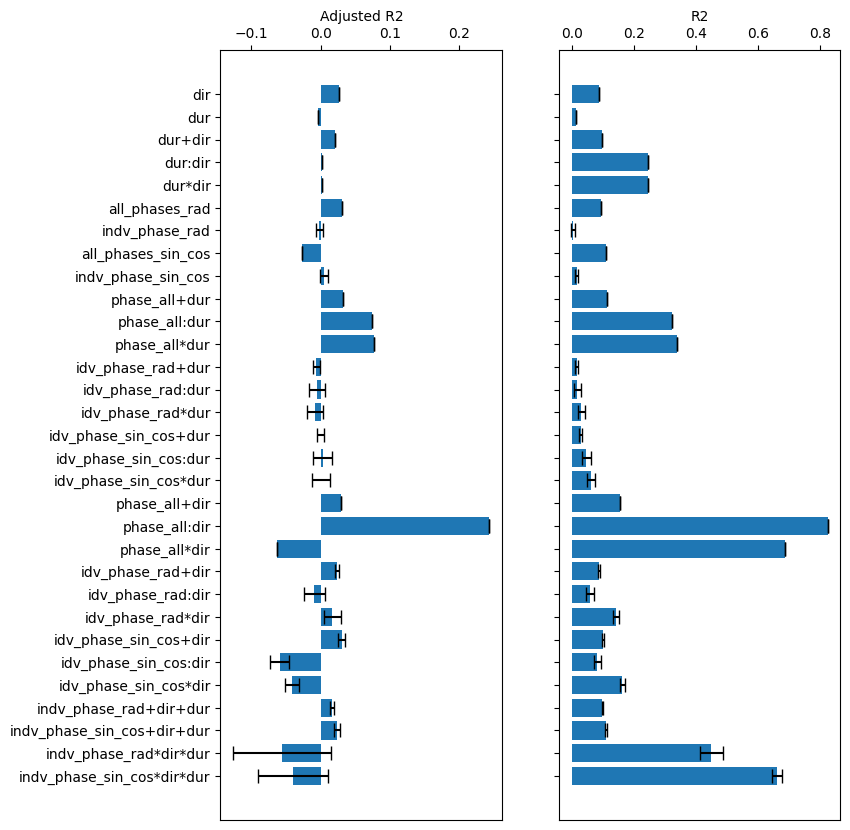

<Figure size 640x480 with 0 Axes>

In [155]:
fig, axs = plt.subplots(1, 2, figsize=(8, 10), sharey='all')

# Loop through res.values() and check if val[1] is a list
means = [np.mean(val[1]) if isinstance(val[1], list) else val[1] for val in res.values()]
stds = [np.std(val[1]) if isinstance(val[1], list) else 0 for val in res.values()]  # Use 0 if not a list for std

# Horizontal bars
axs[0].barh(list(res.keys()), means)
axs[0].errorbar(means, list(res.keys()), xerr=stds, fmt='none', color='black', capsize=5)
axs[0].invert_yaxis()

plt.yticks(rotation=0)  # Ensure y-ticks are horizontal
axs[0].set_xlabel('Adjusted R2')
axs[0].xaxis.set_ticks_position('top')
axs[0].xaxis.set_label_position('top')

# # Loop through res.values() and check if val[1] is a list
means = [np.mean(val[2]) if isinstance(val[2], list) else val[2] for val in res.values()]
stds = [np.std(val[2]) if isinstance(val[2], list) else 0 for val in res.values()]  # Use 0 if not a list for std

# # Horizontal bars
axs[1].barh(list(res.keys()), means)
axs[1].errorbar(means, list(res.keys()), xerr=stds, fmt='none', color='black', capsize=5)
# axs[1].invert_yaxis()

# plt.yticks(rotation=0)  # Ensure y-ticks are horizontal
axs[1].set_xlabel('R2')
axs[1].xaxis.set_ticks_position('top')
axs[1].xaxis.set_label_position('top')
plt.show()
plt.tight_layout()


In [142]:
n_trials = len(td_drop)

############ Generate one-hot encodings ############
values_Sol_direction = td_drop.values_Sol_direction.values
values_Sol_duration = td_drop.values_Sol_duration.values
direction_one_hot = np.eye(12)[values_Sol_direction.astype(int)]

duration_mapping = {50: 0, 100: 1, 150: 2, 200: 3}
duration_mapped = np.array([duration_mapping[val] if val in duration_mapping else -1 for val in td_drop.values_Sol_duration.values])
if np.any(duration_mapped == -1):
    print("Warning: Some values in 'values_Sol_duration' are not 50, 100, 150, or 200.")
duration_one_hot = np.eye(4)[duration_mapped] 

dir_dur_base = (direction_one_hot[:, :, None] * duration_one_hot[:, None, :]).reshape(-1, 48)



################## Gait ################
i=5
perturb_phase_sin = td_drop[f'perturb_phase_{i}_sin'].values
perturb_phase_cos = td_drop[f'perturb_phase_{i}_cos'].values

interaction_sin_dir = perturb_phase_sin[:, None] * direction_one_hot
interaction_cos_dir = perturb_phase_cos[:, None] * direction_one_hot

interaction_sin_dur = perturb_phase_sin[:, None] * duration_one_hot
interaction_cos_dur = perturb_phase_cos[:, None] * duration_one_hot

X_final = np.column_stack([
    # --- Main Effects ---
    # direction_one_hot, 
    # duration_one_hot,
    # dir_dur_base,
    # interaction_sin_dir, 
    # interaction_cos_dir,
    # interaction_sin_dur, 
    # interaction_cos_dur,
    # perturb_phase_sin[:, None] * dir_dur_base,
    # perturb_phase_cos[:, None] * dir_dur_base,

])

r2s = cross_val_score(
    Ridge(alpha=0.01), 
    X=X_final,
    y=td_drop.disturb_sum.values,
    cv=KFold(n_splits=4, shuffle=False),
    scoring=decode.get_custom_scorer()
)
print(r2s.mean(), r2s.std())

0.02034473297390094 0.02018403856568107


In [74]:
X_final.shape

(183, 96)

# Multi-session

In [169]:
SESSIONS = [
    'M061_2025_03_04_10_00', 
    'M061_2025_03_05_14_00', 
    'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30', 
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
    'M103_2026_02_18_15_30',
    'M106_2026_02_25_15_00'

]

In [170]:
all_sessions = dsp.load_sessions_for_trial_analyses(SESSIONS, std_dropping=True)

Loading sessions:   0%|          | 0/9 [00:00<?, ?it/s]


M061_2025_03_04_10_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(


['all_spikes', 'VAL_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']
Resulting all_spikes ephys data shape is (NxT): (53, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (240, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (59, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (112, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (206, 60000)
Resulting CP_spikes ephys data shape is (NxT): (225, 60000)
Skipped 54 trials
Otsu immobility threshold: 2.2328
Dropped 47 of 339 rows (13.86%).


/home/me24/repos/earthquake-analysis/notebooks/standardising/../../tools/dsp/preprocessing.py:193: RuntimeWarning: divide by zero encountered in log10
  lambda a: np.log10(np.abs(np.sum(a)))


...


M106_2026_02_25_15_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']
Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 186  |  by value: 319  |  kept: 180/325 (55.4%)


Loading sessions: 100%|██████████| 9/9 [08:00<00:00, 53.34s/it]


Loaded 9/9 sessions successfully.


In [19]:
from scipy.stats import chi2

null = mixedlm('disturb_sum ~ 1', data=all_sessions_df, groups=all_sessions_df['session']).fit()

lr_stat = 2 * (reduced.llf - null.llf)
df = reduced.df_modelwc - null.df_modelwc
p = chi2.sf(lr_stat, df)
print(f"Omnibus test — direction explains disturb_sum?")
print(f"LR stat={lr_stat:.3f}, df={df}, p={p:.4f}")

Omnibus test — direction explains disturb_sum?
LR stat=35.950, df=11, p=0.0002


In [399]:
from statsmodels.formula.api import mixedlm
kp_1 = 'left_elbow'
kp_2 = 'right_elbow'

kp_3 = 'left_ankle'
kp_4 = 'right_ankle'

dfs = []
t = 195  # 100ms before perturbation onset
idx = 0
for sess, val in all_sessions.items():
    if val is None:
        continue
    td_s = val['td'].copy()

    td_s.loc[:, 'hip_x'] = td_s.apply(
        lambda row: row['hip_center'][t, 0],
        axis=1
    )

    td_s.loc[:, 'hip_y'] = td_s.apply(
        lambda row: row['hip_center'][t, 1],
        axis=1
    )

    td_s.loc[:, 'hip_z'] = td_s.apply(
        lambda row: row['hip_center'][t, 2],
        axis=1
    )

    td_s.loc[:, 'tail'] = td_s.apply(
        lambda row: row['tail_tip'][t, 2],
        axis=1
    )

    # normalise within session
    # td_s['disturb_sum_z'] = (td_s['disturb_sum'] - td_s['disturb_sum'].mean()) / td_s['disturb_sum'].std()
    # td_s['forelimb_distance_z'] = (td_s['forelimb_distance'] - td_s['forelimb_distance'].mean()) / td_s['forelimb_distance'].std()

    dfs.append(td_s)



all_sessions_df = pd.concat(dfs, ignore_index=True).copy()
for col in ['hip_x', 'hip_y', 'hip_z', 'tail']:
    all_sessions_df[f'{col}_c'] = all_sessions_df.groupby('session')[col].transform(lambda x: x - x.mean())
print(f"Total trials: {len(all_sessions_df)}, sessions: {all_sessions_df['session'].nunique()}")

reduced = mixedlm('disturb_sum ~ values_Sol_direction', data=all_sessions_df, groups=all_sessions_df['session']).fit()
print(reduced.summary())

Total trials: 1754, sessions: 9
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     disturb_sum
No. Observations:     1754        Method:                 REML       
No. Groups:           9           Scale:                  0.0852     
Min. group size:      133         Log-Likelihood:         -370.1269  
Max. group size:      255         Converged:              Yes        
Mean group size:      194.9                                          
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.583    0.044 13.345 0.000  0.497  0.668
values_Sol_direction[T.1]  -0.113    0.035 -3.179 0.001 -0.182 -0.043
values_Sol_direction[T.2]   0.018    0.031  0.576 0.565 -0.043  0.078
values_Sol_direction[T.3]  -0.034    0.032 -1.049 0.294 -0.097  0.029
valu

In [400]:
from statsmodels.stats.anova import anova_lm

reduced_ols = ols('disturb_sum ~ C(session) + values_Sol_direction', data=all_sessions_df).fit()
full_ols    = ols('disturb_sum ~ C(session) + values_Sol_direction + hip_x_c * values_Sol_direction + hip_x_c * values_Sol_direction + hip_y_c * values_Sol_direction + hip_z_c * values_Sol_direction + tail * values_Sol_direction',
                  data=all_sessions_df).fit()
# full_ols    = ols('disturb_sum ~ C(session) + values_Sol_direction + hip_x_c + hip_y_c + hip_z_c',
#                   data=all_sessions_df).fit()

print("=== Reduced ===")
print(f"R²={reduced_ols.rsquared:.3f}, adj R²={reduced_ols.rsquared_adj:.3f}, F p={reduced_ols.f_pvalue:.4f}")
print("\n=== Full ===")
print(f"R²={full_ols.rsquared:.3f}, adj R²={full_ols.rsquared_adj:.3f}, F p={full_ols.f_pvalue:.4f}, Cond. No.={full_ols.condition_number:.1f}")

anova = anova_lm(reduced_ols, full_ols)
print("\n=== Nested F-test: does hip position improve over session + direction? ===")
print(anova)

=== Reduced ===
R²=0.187, adj R²=0.178, F p=0.0000

=== Full ===
R²=0.236, adj R²=0.206, F p=0.0000, Cond. No.=30517.0

=== Nested F-test: does hip position improve over session + direction? ===
   df_resid         ssr  df_diff   ss_diff         F    Pr(>F)
0    1734.0  147.754751      0.0       NaN       NaN       NaN
1    1686.0  138.854450     48.0  8.900302  2.251445  0.000003


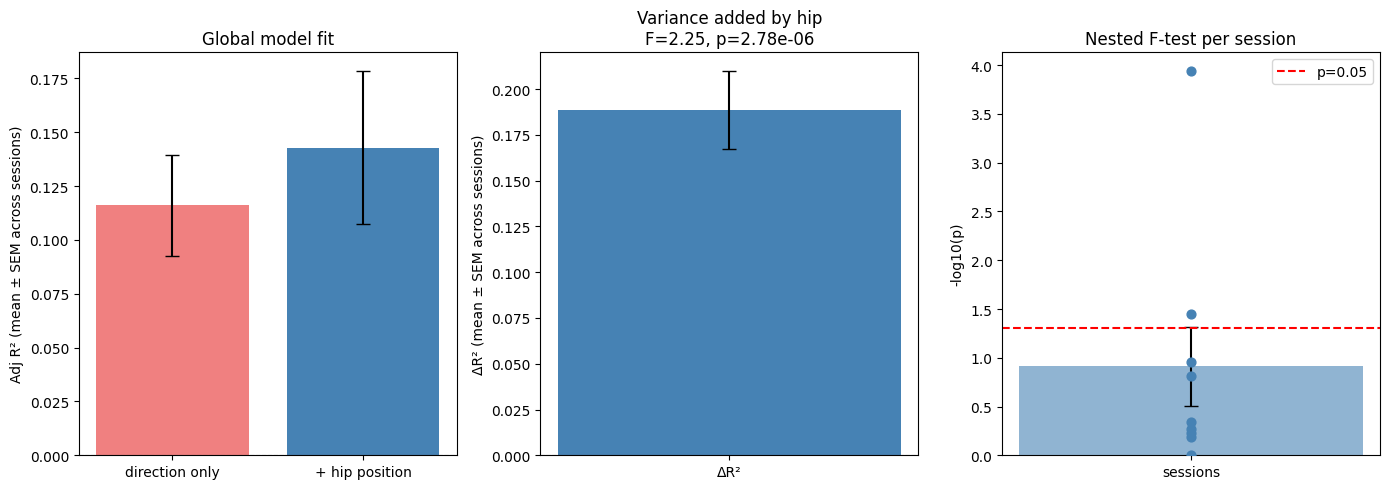

Global: ΔR²=0.049, F=2.25, p=2.78e-06
Per-session ΔR²: mean=0.188 ± SEM=0.021


In [401]:
anova_global = anova_lm(reduced_ols, full_ols)
f_global = anova_global['F'].iloc[1]
p_global = anova_global['Pr(>F)'].iloc[1]
delta_r2_global = full_ols.rsquared - reduced_ols.rsquared

# per-session values for error bars
valid = {k: v for k, v in per_session_results.items() if v is not None}
r2_red_all  = np.array([v['r2_reduced'] for v in valid.values()])
r2_full_all = np.array([v['r2_full']    for v in valid.values()])
delta_all   = np.array([v['delta_r2']   for v in valid.values()])

sem = scipy.stats.sem

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# --- adj R² reduced vs full with SEM across sessions ---
means = [r2_red_all.mean(), r2_full_all.mean()]
sems  = [sem(r2_red_all), sem(r2_full_all)]
axs[0].bar(['direction only', '+ hip position'], means, color=['lightcoral', 'steelblue'],
           yerr=sems, capsize=5, error_kw={'color': 'black'})
axs[0].set_ylabel('Adj R² (mean ± SEM across sessions)')
axs[0].set_title('Global model fit')
axs[0].axhline(0, color='gray', lw=0.8, ls='--')

# --- ΔR² mean ± SEM ---
axs[1].bar(['ΔR²'], [delta_all.mean()], color='steelblue' if p_global < 0.05 else 'lightgray',
           yerr=sem(delta_all), capsize=5, error_kw={'color': 'black'})
axs[1].set_ylabel('ΔR² (mean ± SEM across sessions)')
axs[1].set_title(f'Variance added by hip\nF={f_global:.2f}, p={p_global:.2e}')
axs[1].axhline(0, color='gray', lw=0.8, ls='--')

# --- -log10(p) per session as swarm + mean ---
pvals_all = np.array([v['p'] for v in valid.values()])
log_p = -np.log10(pvals_all)
axs[2].bar(['sessions'], [log_p.mean()], color='steelblue', yerr=sem(log_p), capsize=5,
           error_kw={'color': 'black'}, alpha=0.6)
axs[2].scatter(np.zeros(len(log_p)), log_p, color='steelblue', zorder=3, s=40)
axs[2].axhline(-np.log10(0.05), color='red', ls='--', label='p=0.05')
axs[2].set_ylabel('-log10(p)')
axs[2].set_title('Nested F-test per session')
axs[2].legend()

plt.tight_layout()
plt.show()

print(f"Global: ΔR²={delta_r2_global:.3f}, F={f_global:.2f}, p={p_global:.2e}")
print(f"Per-session ΔR²: mean={delta_all.mean():.3f} ± SEM={sem(delta_all):.3f}")

In [402]:
print(full_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            disturb_sum   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     7.779
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.82e-60
Time:                        17:02:16   Log-Likelihood:                -264.55
No. Observations:                1754   AIC:                             665.1
Df Residuals:                    1686   BIC:                             1037.
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [403]:
session_only = ols('disturb_sum ~ C(session)', data=all_sessions_df).fit()

anova_dir = anova_lm(session_only, reduced_ols)
print("=== Omnibus: does direction explain disturb_sum beyond session? ===")
print(anova_dir)

=== Omnibus: does direction explain disturb_sum beyond session? ===
   df_resid         ssr  df_diff    ss_diff          F        Pr(>F)
0    1745.0  159.471920      0.0        NaN        NaN           NaN
1    1734.0  147.754751     11.0  11.717169  12.500795  5.013761e-23


In [404]:
per_session_results = {}

for sess in all_sessions_df['session'].unique():
    td_s = all_sessions_df[all_sessions_df['session'] == sess].copy()

    # centre hip within this session
    for col in ['hip_x', 'hip_y', 'hip_z', 'tail']:
        td_s[f'{col}_c'] = td_s[col] - td_s[col].mean()

    try:
        red = ols('disturb_sum ~ values_Sol_direction', data=td_s).fit()
        full = ols('disturb_sum ~ values_Sol_direction + hip_x_c * values_Sol_direction + hip_y_c * values_Sol_direction + hip_z_c * values_Sol_direction', data=td_s).fit()
        anova = anova_lm(red, full)
        f_stat = anova['F'].iloc[1]
        p_val  = anova['Pr(>F)'].iloc[1]
        delta_r2 = full.rsquared - red.rsquared
        per_session_results[sess] = dict(n=len(td_s), r2_reduced=red.rsquared_adj, r2_full=full.rsquared_adj, delta_r2=delta_r2, F=f_stat, p=p_val)
        print(f"{sess}  n={len(td_s)}  adj R²: {red.rsquared_adj:.3f} → {full.rsquared_adj:.3f}  ΔR²={delta_r2:.3f}  F={f_stat:.2f}  p={p_val:.4f}")
    except Exception as e:
        print(f"{sess}  FAILED: {e}")
        per_session_results[sess] = None

M061_2025_03_04_10_00  n=179  adj R²: 0.197 → 0.240  ΔR²=0.194  F=1.26  p=0.1722
M061_2025_03_05_14_00  n=133  adj R²: 0.186 → 0.208  ΔR²=0.236  F=1.09  p=0.3641
M061_2025_03_06_14_00  n=190  adj R²: 0.197 → 0.287  ΔR²=0.220  F=1.62  p=0.0250
M062_2025_03_20_14_00  n=191  adj R²: 0.152 → 0.129  ΔR²=0.143  F=0.87  p=0.6806
M062_2025_03_21_14_00  n=205  adj R²: 0.055 → 0.122  ΔR²=0.218  F=1.40  p=0.0812
M078_2025_08_06_15_00  n=255  adj R²: 0.071 → 0.149  ΔR²=0.195  F=1.62  p=0.0202
M086_2025_12_10_15_00  n=195  adj R²: 0.074 → 0.065  ΔR²=0.165  F=0.95  p=0.5584
M103_2026_02_18_15_30  n=226  adj R²: 0.109 → 0.163  ΔR²=0.186  F=1.39  p=0.0858
M106_2026_02_25_15_00  n=180  adj R²: 0.002 → 0.296  ΔR²=0.417  F=2.94  p=0.0000


/tmp/ipykernel_1691205/3916950911.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(short_names, rotation=45, ha='right')
/tmp/ipykernel_1691205/3916950911.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(short_names, rotation=45, ha='right')


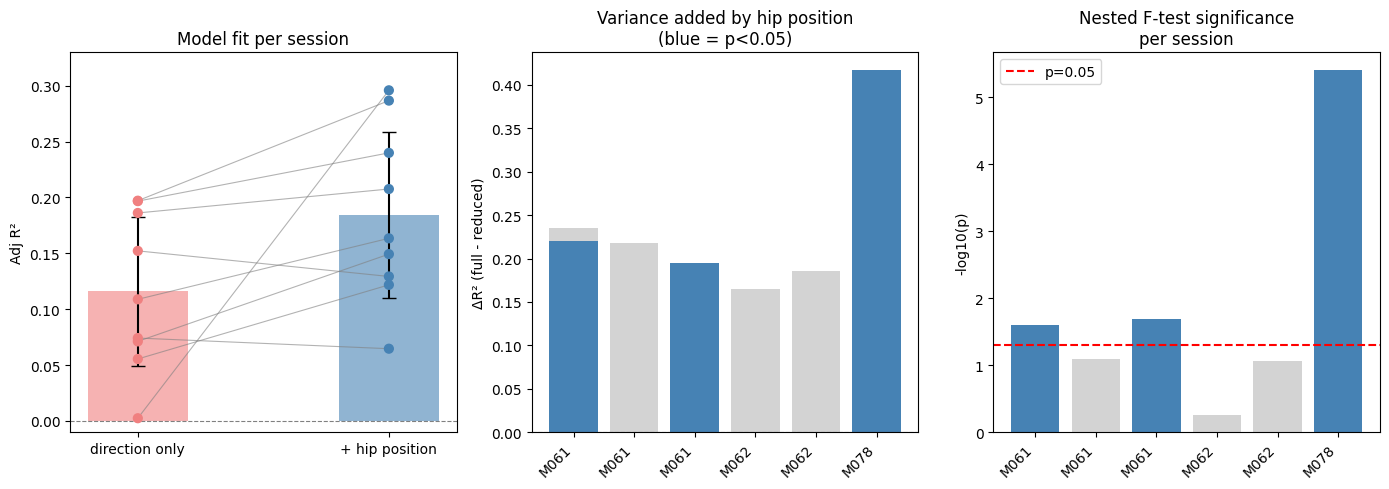

M061  adj R²: 0.197 → 0.240  ΔR²=0.194  p=0.1722  ns
M061  adj R²: 0.186 → 0.208  ΔR²=0.236  p=0.3641  ns
M061  adj R²: 0.197 → 0.287  ΔR²=0.220  p=0.0250  *
M062  adj R²: 0.152 → 0.129  ΔR²=0.143  p=0.6806  ns
M062  adj R²: 0.055 → 0.122  ΔR²=0.218  p=0.0812  ns
M078  adj R²: 0.071 → 0.149  ΔR²=0.195  p=0.0202  *
M086  adj R²: 0.074 → 0.065  ΔR²=0.165  p=0.5584  ns
M103  adj R²: 0.109 → 0.163  ΔR²=0.186  p=0.0858  ns
M106  adj R²: 0.002 → 0.296  ΔR²=0.417  p=0.0000  *


In [405]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

valid = {k: v for k, v in per_session_results.items() if v is not None}
sessions = list(valid.keys())
short_names = [s[:4] for s in sessions]
r2_red  = np.array([v['r2_reduced'] for v in valid.values()])
r2_full = np.array([v['r2_full']    for v in valid.values()])
delta   = np.array([v['delta_r2']   for v in valid.values()])
pvals   = np.array([v['p']          for v in valid.values()])

# --- adj R²: summary bars + individual session dots connected by lines ---
axs[0].bar([0, 1], [r2_red.mean(), r2_full.mean()], color=['lightcoral', 'steelblue'],
        #    yerr=[scipy.stats.sem(r2_red), scipy.stats.sem(r2_full)],
        yerr=[np.std(r2_red), np.std(r2_full)],
           capsize=5, error_kw={'color': 'black'}, alpha=0.6, width=0.4)
for r, f in zip(r2_red, r2_full):
    axs[0].plot([0, 1], [r, f], color='gray', lw=0.8, alpha=0.6)
    axs[0].scatter([0, 1], [r, f], color=['lightcoral', 'steelblue'], zorder=3, s=40)
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['direction only', '+ hip position'])
axs[0].set_ylabel('Adj R²')
axs[0].set_title('Model fit per session')
axs[0].axhline(0, color='gray', lw=0.8, ls='--')
axs[0].set_ylim(-0.01, 0.33)
# --- ΔR² per session ---
colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]
axs[1].bar(short_names, delta, color=colors)
axs[1].set_ylabel('ΔR² (full - reduced)')
axs[1].set_title('Variance added by hip position\n(blue = p<0.05)')
axs[1].axhline(0, color='gray', lw=0.8, ls='--')
axs[1].set_xticklabels(short_names, rotation=45, ha='right')

# --- -log10(p) per session ---
axs[2].bar(short_names, -np.log10(pvals), color=colors)
axs[2].axhline(-np.log10(0.05), color='red', ls='--', label='p=0.05')
axs[2].set_ylabel('-log10(p)')
axs[2].set_title('Nested F-test significance\nper session')
axs[2].legend()
axs[2].set_xticklabels(short_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

for s, r, f, d, p in zip(short_names, r2_red, r2_full, delta, pvals):
    sig = '*' if p < 0.05 else 'ns'
    print(f"{s}  adj R²: {r:.3f} → {f:.3f}  ΔR²={d:.3f}  p={p:.4f}  {sig}")

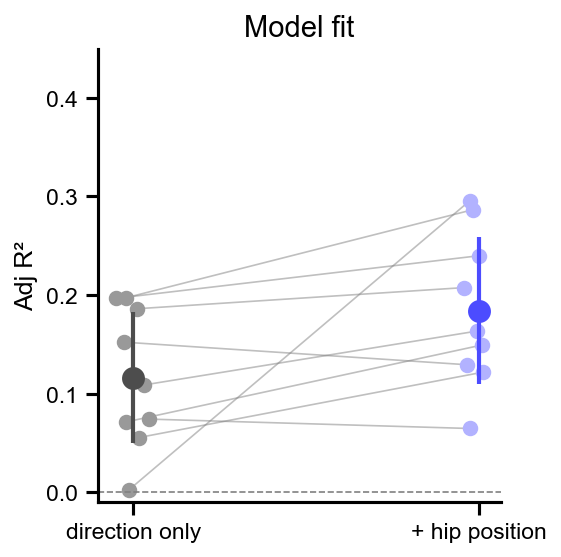

In [406]:
from tools.viz.rc_style import rc_context_talk

# colors
c_red  = '0.6'
c_blue = plt.cm.bwr(0.15)

# jitter
jitter = 0.05
x0 = 0 + np.random.uniform(-jitter, jitter, size=len(r2_red))
x1 = 1 + np.random.uniform(-jitter, jitter, size=len(r2_full))


# means and std
means = [r2_red.mean(), r2_full.mean()]
errs  = [np.std(r2_red), np.std(r2_full)]

# errorbars (front)
with rc_context_talk():
    fig, ax = plt.subplots(figsize=(4, 4))

    
    # scatter + connecting lines (behind)
    for xi0, xi1, r, f in zip(x0, x1, r2_red, r2_full):
        ax.plot([xi0, xi1], [r, f], color='gray', lw=0.8, alpha=0.5, zorder=1)
        ax.scatter(xi0, r, color=c_red, alpha=1, s=35, zorder=2)
        ax.scatter(xi1, f, color=plt.cm.bwr(0.35), alpha=1, s=35, zorder=2)

    ax.errorbar(0, means[0], yerr=errs[0], fmt='o',
                color='0.3',capsize=0, zorder=3, ms=10)

    ax.errorbar(1, means[1], yerr=errs[1], fmt='o',
                color=c_blue, ecolor=c_blue,
                elinewidth=2, capsize=0, zorder=3, ms=10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['direction only', '+ hip position'])
    ax.set_ylabel('Adj R²')
    ax.set_title('Model fit')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_ylim(-0.01, 0.45)

    plt.tight_layout()
    plt.show()

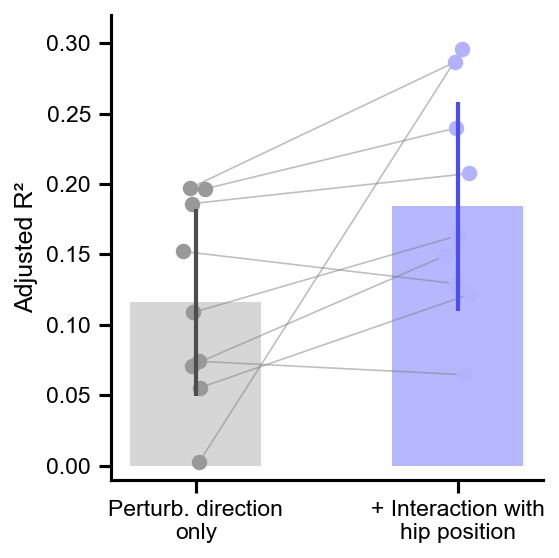

In [410]:
from tools.viz.rc_style import rc_context_talk

# colors
c_red  = '0.6'
c_blue = plt.cm.bwr(0.15)

# jitter
jitter = 0.05
x0 = 0 + np.random.uniform(-jitter, jitter, size=len(r2_red))
x1 = 1 + np.random.uniform(-jitter, jitter, size=len(r2_full))

# means and std
means = [r2_red.mean(), r2_full.mean()]
errs  = [np.std(r2_red), np.std(r2_full)]

with rc_context_talk():
    fig, ax = plt.subplots(figsize=(4, 4))

    # --- bars (background) ---
    ax.bar(0, means[0], color=c_red, alpha=0.4, width=0.5, zorder=0)
    ax.bar(1, means[1], color=c_blue, alpha=0.4, width=0.5, zorder=0)

    # --- scatter + connecting lines ---
    for xi0, xi1, r, f in zip(x0, x1, r2_red, r2_full):
        ax.plot([xi0, xi1], [r, f], color='gray', lw=0.8, alpha=0.5, zorder=1)
        ax.scatter(xi0, r, color=c_red, alpha=1, s=35, zorder=2)
        ax.scatter(xi1, f, color=plt.cm.bwr(0.35), alpha=1, s=35, zorder=2)

    # --- errorbars (on top of bars) ---
    ax.errorbar(0, means[0], yerr=errs[0], fmt='none',
                ecolor='0.3', elinewidth=2, capsize=0, zorder=3)

    ax.errorbar(1, means[1], yerr=errs[1], fmt='none',
                ecolor=c_blue, elinewidth=2, capsize=0, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Perturb. direction\nonly', '+ Interaction with\nhip position'])
    ax.set_ylabel('Adjusted R²')
    # ax.set_title('t = +3s')
    # ax.axhline(0, color='gray', ls='--')
    ax.set_ylim(-0.01, 0.32)

    plt.tight_layout()
    plt.show()
    fig.savefig('../../results/pdfs/model_fit1.svg', bbox_inches='tight')
